Pattern Recognition Homework 1 - 
=

# Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
'''
debug print
'''
DEBUG = True

def printd(*args, **kwargs):
    if DEBUG:
        print(*args, **kwargs)

# Generate Data

The data is 3-dimensional with three classes with specified means and covariance matrix, and some uninformative noise dimensions generated with zero mean and a specified variance.

In [3]:
# Specify dimensions, number of clases, and number of samples per class
dimensions = 3
num_classes = 3
num_samples_per_class = 100



In [4]:
#define class means
class_means = np.array([[2,2,0],
                       [-2,2,0],
                       [0,-2,0]], 
                       dtype=np.float32)
class_means

array([[ 2.,  2.,  0.],
       [-2.,  2.,  0.],
       [ 0., -2.,  0.]], dtype=float32)

In [5]:
# define covariance matrix among the classes
covariance = np.array([[1.0, 0.6,0],
                             [0.6, 1.5, 0],
                             [0,0,0.5]],
                            dtype=np.float32)
covariance

array([[1. , 0.6, 0. ],
       [0.6, 1.5, 0. ],
       [0. , 0. , 0.5]], dtype=float32)

## Generate Synthetic Random Multivariate Data

In [6]:
# generate the data for three classes
# set random seed
rng = np.random.default_rng(seed=25)

# generate standard normal samples 
sample_data = []
for i in range(num_classes):
    sample_data.append(rng.standard_normal((num_samples_per_class, dimensions)))
printd(sample_data[0].min(), sample_data[0].max(), sample_data[0].shape)

# use Cholesky decomposition to decompose the covariance matrix into the product
# of a lower triangular matrix and its transpose.
L = np.linalg.cholesky(covariance)
printd(L)
printd(L @ L.T)
printd(covariance)

# transform the data with the mean and covariance
for i in range(num_classes):
    sample_data[i] = class_means[i] + sample_data[i] @ L.T
    printd(f"Class {i}: ", sample_data[i].mean(axis=0), sample_data[i].min(axis=0), sample_data[i].max(axis=0))

-2.4453801820724297 3.370023181831863 (100, 3)
[[1.         0.         0.        ]
 [0.6        1.0677078  0.        ]
 [0.         0.         0.70710677]]
[[1.         0.6        0.        ]
 [0.6        1.4999999  0.        ]
 [0.         0.         0.49999997]]
[[1.  0.6 0. ]
 [0.6 1.5 0. ]
 [0.  0.  0.5]]
Class 0:  [2.02018937 2.05819058 0.02195273] [-0.33032588 -1.32226032 -1.62813087] [4.80219183 4.60543534 2.3829662 ]
Class 1:  [-1.942207    2.11459581 -0.04157584] [-4.20463215 -0.56963855 -2.06626432] [0.31253754 4.35711082 1.71750176]
Class 2:  [ 0.0267686  -1.93596624  0.05470097] [-1.92595512 -4.45886364 -1.3995467 ] [2.07664018 0.42973087 1.7808716 ]


## Generate Random Noise

In [7]:
# generate noise 
# set random seed
rng = np.random.default_rng(seed=25)

noise_mean = 0.0
noise_stdev = np.sqrt(0.5)
num_noise_dimensions = 10

noise = rng.normal(loc=noise_mean, scale=noise_stdev, size = (num_samples_per_class, num_noise_dimensions))
printd(noise.mean(axis=0), noise.std(axis=0))
printd(noise.shape)

[-0.05022312  0.07142925  0.21043292 -0.05672072  0.05493059 -0.03212811
  0.01259905  0.05112516 -0.01823378  0.04938577] [0.62054322 0.72132359 0.72661286 0.60863727 0.70006698 0.68620548
 0.74514741 0.65150861 0.7048021  0.77921413]
(100, 10)


## Mahalanobis distance

In [8]:
from scipy.spatial import distance 

inv_covariance = np.linalg.pinv(covariance)
# x is a point
# d = distance.mahalanobis(x, mean, inv_covariance)


## Plot the data in 2D

(200, 200)
(200, 200)
(40000, 2)
(40000, 2)
(200, 200)
(200, 200)
(40000, 2)
(40000, 2)
(200, 200)
(200, 200)
(40000, 2)
(40000, 2)


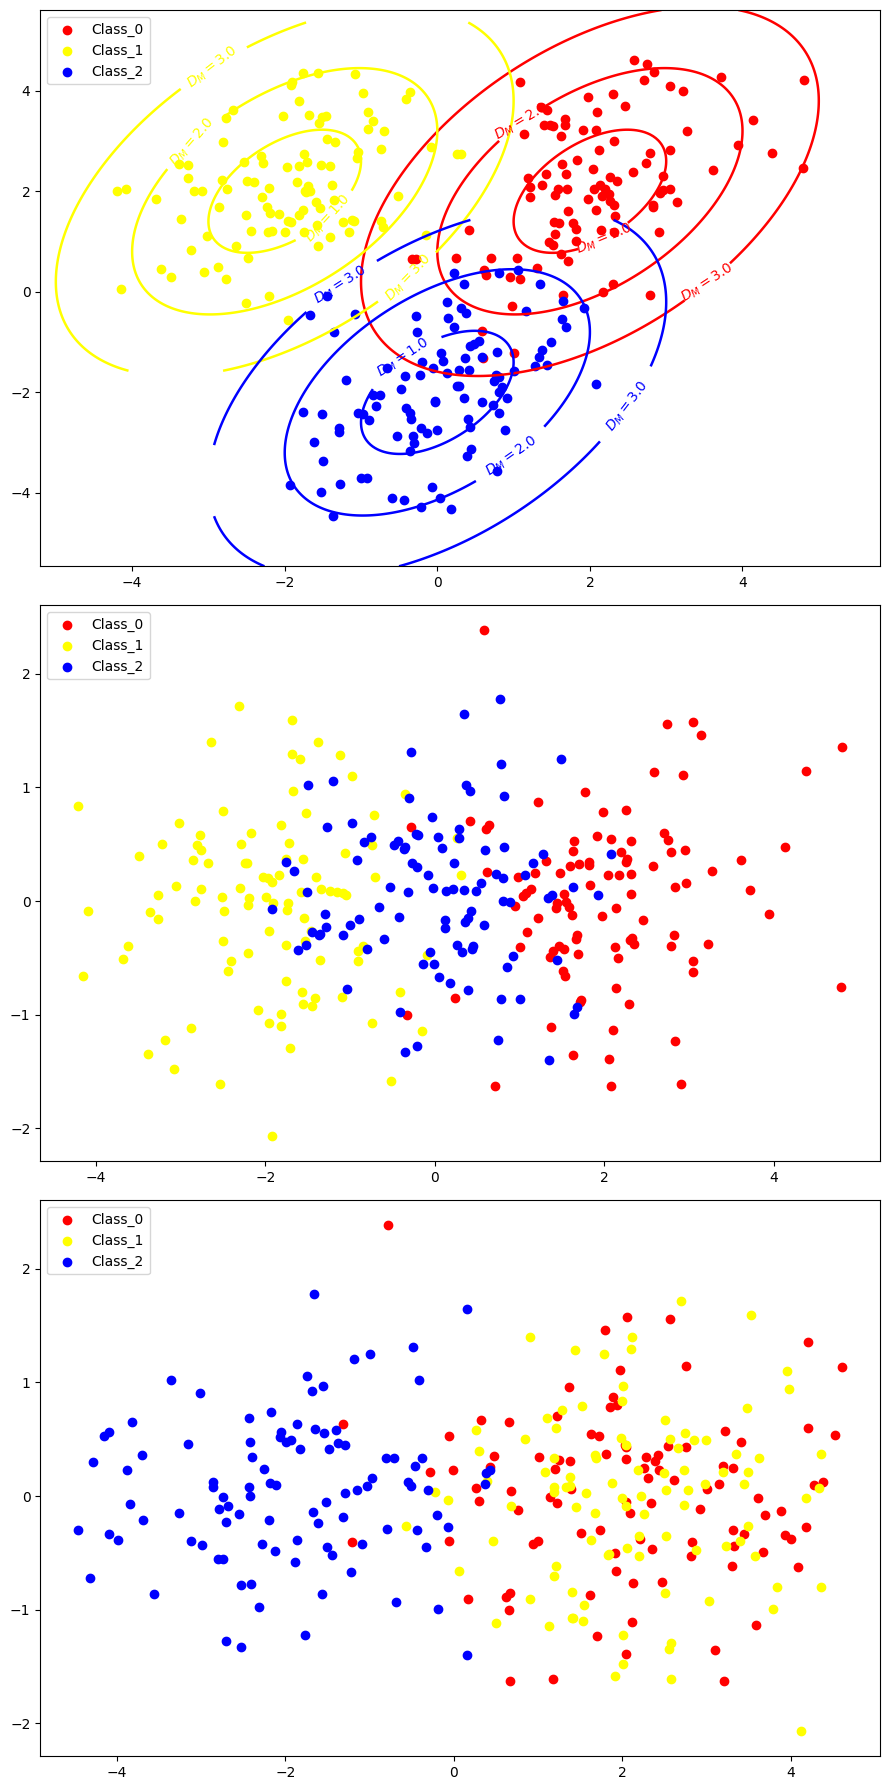

In [32]:
fig, ax = plt.subplots(nrows=3,figsize = (9,18))



class_num = 0
ax[0].scatter(sample_data[class_num][:,0], sample_data[class_num][:,1], label = f"Class_{class_num}", color = "red")
# create 2D coordinate grid
x_grid = np.linspace(sample_data[class_num][:,0].min() - 1, sample_data[class_num][:,0].max() + 1, 200)
y_grid = np.linspace(sample_data[class_num][:,1].min() - 1, sample_data[class_num][:,1].max() + 1, 200)
XX, YY = np.meshgrid(x_grid, y_grid)
print(XX.shape)
print(YY.shape)
grid_points = np.c_[XX.ravel(), YY.ravel()]
print(grid_points.shape)
diff = grid_points - class_means[class_num][0:2]
print(diff.shape)
# print(inv_covariance[0:2,:].shape)
dist_sq = np.sum(np.dot(diff, inv_covariance[0:2,0:2]) * diff, axis = 1)
dist_grid = np.sqrt(dist_sq).reshape(XX.shape)
levels = [1.0,2.0,3.0]
cs = ax[0].contour(XX, YY, dist_grid, levels = levels, colors = ['red', 'red', 'red'], linewidths=1.8)
ax[0].clabel(cs, inline=True, fmt=r'$D_M = %.1f$', fontsize=10)

class_num = 1
ax[0].scatter(sample_data[class_num][:,0], sample_data[class_num][:,1], label = f"Class_{class_num}", color = "yellow")
# create 2D coordinate grid
x_grid = np.linspace(sample_data[class_num][:,0].min() - 1, sample_data[class_num][:,0].max() + 1, 200)
y_grid = np.linspace(sample_data[class_num][:,1].min() - 1, sample_data[class_num][:,1].max() + 1, 200)
XX, YY = np.meshgrid(x_grid, y_grid)
print(XX.shape)
print(YY.shape)
grid_points = np.c_[XX.ravel(), YY.ravel()]
print(grid_points.shape)
diff = grid_points - class_means[class_num][0:2]
print(diff.shape)
# print(inv_covariance[0:2,:].shape)
dist_sq = np.sum(np.dot(diff, inv_covariance[0:2,0:2]) * diff, axis = 1)
dist_grid = np.sqrt(dist_sq).reshape(XX.shape)
levels = [1.0,2.0,3.0]
cs = ax[0].contour(XX, YY, dist_grid, levels = levels, colors = ['yellow', 'yellow', 'yellow'], linewidths=1.8)
ax[0].clabel(cs, inline=True, fmt=r'$D_M = %.1f$', fontsize=10)

class_num = 2
ax[0].scatter(sample_data[class_num][:,0], sample_data[class_num][:,1], label = f"Class_{class_num}", color = "blue")
# create 2D coordinate grid
x_grid = np.linspace(sample_data[class_num][:,0].min() - 1, sample_data[class_num][:,0].max() + 1, 200)
y_grid = np.linspace(sample_data[class_num][:,1].min() - 1, sample_data[class_num][:,1].max() + 1, 200)
XX, YY = np.meshgrid(x_grid, y_grid)
print(XX.shape)
print(YY.shape)
grid_points = np.c_[XX.ravel(), YY.ravel()]
print(grid_points.shape)
diff = grid_points - class_means[class_num][0:2]
print(diff.shape)
# print(inv_covariance[0:2,:].shape)
dist_sq = np.sum(np.dot(diff, inv_covariance[0:2,0:2]) * diff, axis = 1)
dist_grid = np.sqrt(dist_sq).reshape(XX.shape)
levels = [1.0,2.0,3.0]
cs = ax[0].contour(XX, YY, dist_grid, levels = levels, colors = ['blue', 'blue', 'blue'], linewidths=1.8)
ax[0].clabel(cs, inline=True, fmt=r'$D_M = %.1f$', fontsize=10)

ax[0].legend(loc='upper left')


class_num = 0
ax[1].scatter(sample_data[class_num][:,0], sample_data[class_num][:,2], label = f"Class_{class_num}", color = "red")
class_num = 1
ax[1].scatter(sample_data[class_num][:,0], sample_data[class_num][:,2], label = f"Class_{class_num}", color = "yellow")
class_num = 2
ax[1].scatter(sample_data[class_num][:,0], sample_data[class_num][:,2], label = f"Class_{class_num}", color = "blue")
ax[1].legend(loc='upper left')

class_num = 0
ax[2].scatter(sample_data[class_num][:,1], sample_data[class_num][:,2], label = f"Class_{class_num}", color = "red")
class_num = 1
ax[2].scatter(sample_data[class_num][:,1], sample_data[class_num][:,2], label = f"Class_{class_num}", color = "yellow")
class_num = 2
ax[2].scatter(sample_data[class_num][:,1], sample_data[class_num][:,2], label = f"Class_{class_num}", color = "blue")
ax[2].legend(loc='upper left')




plt.tight_layout()
plt.show()

## Plot the data in 3D

# Hughes' Phenomenon

# Spatial whitening with PCA and Ridge Regularization

# Supervised Dimensionality Reduction

# Iris Dataset Experiment